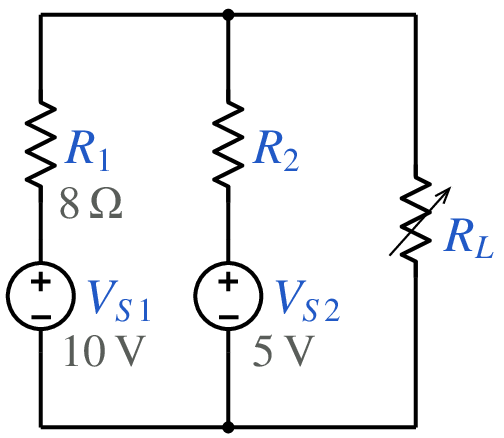

In [1]:
from IPython.display import Image
Image(filename =r'dc_circuit_3_fig_1.png', width=180)

In [2]:
netlist = """\
DC Circuit 3 — Max Power Transfer
Vs1  B  0  DC  10
R1   A  B  8
Vs2  C  0  DC  5
R2   A  C  $R2
RL   A  0  $RL
.SAVE v(a) i(Vs1) i(Vs2)
.DC RL 0.01 100 0.05
.END
"""

with open('dc_circuit_3_orig.in', 'w') as f:
    f.write(netlist)

print('dc_circuit_3_orig.in written')

dc_circuit_3_orig.in written


In [16]:
import numpy as np
import ngspice_calc as calc
import matplotlib.pyplot as plt

s_R2 = '12'     

print(f'R2 = {s_R2} Ω')
print(f'Vs1 = 10 V,  R1 = 8 Ω')
print(f'Vs2 = 5 V')

R2 = 12 Ω
Vs1 = 10 V,  R1 = 8 Ω
Vs2 = 5 V


In [17]:
l = [
    ('$R2', s_R2),
    ('$RL', '10'),    
]

calc.replace_strings_1('dc_circuit_3_orig.in', 'dc_circuit_3.in', l)
calc.run_ngspice('dc_circuit_3.in')


No compatibility mode selected!


Circuit: dc circuit 3 — max power transfer

binary raw file "dc_circuit_3.raw"
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

No. of Data Columns : 4  

No. of Data Rows : 2000

Total analysis time (seconds) = 0.038

Total elapsed time (seconds) = 0.041 

Total DRAM available = 14741.164 MB.
DRAM currently available = 4065.914 MB.
Maximum ngspice program size =   19.910 MB.
Current ngspice program size =   11.973 MB.

Shared ngspice pages =   10.113 MB.
Text (code) pages =    5.316 MB.
Stack = 0 bytes.
Library pages =    1.965 MB.




'dc_circuit_3.raw'

In [18]:
s = calc.slv('dc_circuit_3.in')

for i in range(s.num_plots()):
    print(f"  plot {i}: {s.plotname(i)} | type: {s.analysis_type(i)} | vars: {s.variables(i)}")

  plot 0: DC transfer characteristic | type: tran | vars: ['res-sweep', 'v(a)', 'i(vs1)', 'i(vs2)']


In [ ]:

RL_arr = s.get_array('res-sweep')     
VA_arr = s.get_array('v(a)')       

PL_arr = (VA_arr ** 2) / RL_arr

# Find RL at maximum power
k_max = np.argmax(PL_arr)
RL_max = RL_arr[k_max]
PL_max = PL_arr[k_max]

s_format = "%11.4E"
print(f'RL (approx) for maximum power : {RL_max:{s_format[1:]}} Ω')
print(f'Maximum power                 : {PL_max:{s_format[1:]}} W')
print()
print(f'Expected RL for max power = 4.8 Ω')
print(f'Difference = {abs(RL_max - 4.8):.4f} Ω')

RL (approx) for maximum power :  4.8100E+00 Ω
Maximum power                 :  3.3333E+00 W

Expected RL for max power = 4.8 Ω
Difference = 0.0100 Ω


In [ ]:

R2_val = float(s_R2)
Vth = (10/8 + 5/R2_val) / (1/8 + 1/R2_val)

# Rth: kill sources (short Vs1, Vs2) → R1 || R2
Rth = (8 * R2_val) / (8 + R2_val)

print('Thevenin Equivalent')
print(f'Vth = {Vth:.4f} V')
print(f'Rth = {Rth:.4f} Ω')
print()
print(f'Max power transfer when RL = Rth = {Rth:.4f} Ω')
print(f'NGSPICE found max at RL = {RL_max:.4f} Ω')
print()

# Max power = Vth^2 / (4 * Rth)
PL_theory = Vth**2 / (4 * Rth)
print(f'Max power (theory) = {PL_theory:.6f} W')
print(f'Max power (NGSPICE)= {PL_max:.6f} W')

Thevenin Equivalent
Vth = 8.0000 V
Rth = 4.8000 Ω

Max power transfer when RL = Rth = 4.8000 Ω
NGSPICE found max at RL = 4.8100 Ω

Max power (theory) = 3.333333 W
Max power (NGSPICE)= 3.333330 W


In [21]:


R1 = 8.0
Rth_target = 4.8
R2_required = (Rth_target * R1) / (R1 - Rth_target)

print(f'For max power at RL = 4.8 Ω:')
print(f'Required R2 = {R2_required:.4f} Ω')
print()
print(f'Current s_R2 = {s_R2} Ω  →  Rth = {Rth:.4f} Ω')
print(f'Set s_R2 = "{R2_required:.1f}" in Cell 2 and re-run to verify.')

For max power at RL = 4.8 Ω:
Required R2 = 12.0000 Ω

Current s_R2 = 12 Ω  →  Rth = 4.8000 Ω
Set s_R2 = "12.0" in Cell 2 and re-run to verify.


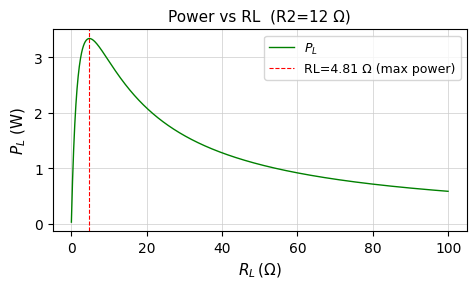

In [22]:
color1 = 'green'

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(RL_arr, PL_arr, color=color1, linewidth=1.0, label=r'$P_L$')
ax.axvline(x=RL_max, color='red', linestyle='--', linewidth=0.8,
           label=f'RL={RL_max:.2f} Ω (max power)')
ax.set_xlabel(r'$R_L\,(\Omega)$', fontsize=11)
ax.set_ylabel(r'$P_L$' + ' (W)', fontsize=11)
ax.set_title(f'Power vs RL  (R2={s_R2} Ω)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(color='#CCCCCC', linestyle='solid', linewidth=0.5)
plt.tight_layout()
plt.show()